# Check Unity GT vs SAM3D Body Keypoints

对比 Unity GT character 关键点和 SAM3D Body 预测关键点的 3D 可视化。

- Unity GT：`data_pole_ski/{gender}/{action}/kpt3d/character/frame_XXXXXX.npy`（需绕 X 轴旋转 180°）
- SAM3D Body：`sam3d_body_results/inference/{gender}/{action}/frames/{camera}/XXXXXX_sam3d_body.npz`

In [21]:
import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pose2equip.map_config import (
    FILTERED_KPTS_MAPPING, SKI_MAPPING, POLE_MAPPING,
    FILTER_SKELETON_CONNECTIONS,
    filter_sam3d_body_kpts,
    filter_unity_kpts,
)

# ── 可调参数 ────────────────────────────────────────────────────────────────
GENDER      = "female"
ACTION      = "Anim_Female_Skier_Idle"
CAMERA      = "capture_L0_A000"   # SAM3D body 子目录
FRAME_IDX   = 1                   # 帧编号（0-based）
# ─────────────────────────────────────────────────────────────────────────────

DATA_ROOT = Path("/workspace/data/skiing_unity_dataset")

unity_char_dir  = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "character"
sam3d_body_dir  = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt3d" / CAMERA

print("Unity GT dir :", unity_char_dir)
print("SAM3D dir    :", sam3d_body_dir)
print("Unity files  :", len(list(unity_char_dir.glob("*.npy"))))
print("SAM3D files  :", len(list(sam3d_body_dir.glob("*.npy"))))

Unity GT dir : /workspace/data/skiing_unity_dataset/data_pole_ski/female/Anim_Female_Skier_Idle/kpt3d/character
SAM3D dir    : /workspace/data/skiing_unity_dataset/sam3d_body_results/modalities_from_sam3d/female/Anim_Female_Skier_Idle/kpt3d/capture_L0_A000
Unity files  : 40
SAM3D files  : 40


In [22]:
def load_unity_character(frame_idx: int, flag: str) -> np.ndarray:
    """读取 Unity GT character 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_char_dir / f"frame_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    return filter_unity_kpts(raw, flag=flag, gender=GENDER)          # [15, 3]


def load_sam3d_body(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 关键点（kpt3d），过滤到 15 关节。"""
    path = sam3d_body_dir / f"kpt3d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 3) → (J, 3)
    return filter_sam3d_body_kpts(raw)     # [15, 3]


# 加载并打印形状
unity_kpt = load_unity_character(FRAME_IDX, flag="3d")
sam3d_kpt = load_sam3d_body(FRAME_IDX)
print("Unity GT  shape:", unity_kpt.shape)
print("SAM3D body shape:", sam3d_kpt.shape)
print("\nUnity GT (前3关节):\n",  unity_kpt[:3])
print("\nSAM3D body (前3关节):\n", sam3d_kpt[:3])

Unity GT  shape: (15, 3)
SAM3D body shape: (15, 3)

Unity GT (前3关节):
 [[-0.04010222  1.0953739   0.6025025 ]
 [ 0.01903435  1.0960875   0.6009971 ]
 [-0.14953063  1.0382113   0.3996973 ]]

SAM3D body (前3关节):
 [[ 0.02809618 -1.5695341  -0.07400927]
 [-0.03539629 -1.5720401  -0.06865114]
 [ 0.18836522 -1.3662792   0.08748056]]


In [23]:
import numpy as np

def normalize(v, eps=1e-8):
    return v / (np.linalg.norm(v, axis=-1, keepdims=True) + eps)

def canonicalize_pose_numpy(
    x,
    left_hip,
    right_hip,
    neck,
    mode="first_frame",
    eps=1e-8,
    enforce_face_z_positive=False,
    left_eye=None,
    right_eye=None,
):

    """
    x: (J, 3) or (T, J, 3)
    mode:
        "per_frame"
        "first_frame"
    enforce_face_z_positive:
        当提供 left_eye/right_eye 且为 True 时，强制 +Z 与(双眼中点-颈部)同向
    return:
        x_canon: same shape as x
        transform dict with pelvis and R
    """

    x = np.asarray(x, dtype=np.float32)

    squeeze_time = False
    if x.ndim == 2:
        x = x[None, ...]
        squeeze_time = True
    elif x.ndim != 3:
        raise ValueError("x must have shape (J, 3) or (T, J, 3)")

    left_hip_pos = x[:, left_hip]
    right_hip_pos = x[:, right_hip]
    neck_pos = x[:, neck]

    pelvis = (left_hip_pos + right_hip_pos) / 2.0
    x_centered = x - pelvis[:, None, :]

    x_axis = normalize(right_hip_pos - left_hip_pos, eps)  # body right
    y_axis = normalize(neck_pos - pelvis, eps)             # body up

    z_axis = normalize(np.cross(x_axis, y_axis), eps)      # forward/back (unsigned)

    if enforce_face_z_positive and left_eye is not None and right_eye is not None:
        eye_mid = (x[:, left_eye] + x[:, right_eye]) / 2.0
        face_dir = normalize(eye_mid - neck_pos, eps)
        sign = np.sign(np.sum(z_axis * face_dir, axis=-1, keepdims=True))
        sign[sign == 0] = 1.0
        z_axis = z_axis * sign

    # y_axis = normalize(np.cross(z_axis, x_axis), eps)      # re-orthogonalized up
    R = np.stack([x_axis, y_axis, z_axis], axis=-1)

    if mode == "first_frame":
        ref_pelvis = pelvis[0]
        ref_R = R[0]
        x_canon = np.matmul(x - ref_pelvis[None, None, :], ref_R)
        transform = {"pelvis": ref_pelvis, "R": ref_R}
    elif mode == "per_frame":
        x_canon = np.einsum("tjc,tck->tjk", x_centered, R)
        transform = {"pelvis": pelvis, "R": R}
    else:
        raise ValueError("mode must be first_frame or per_frame")

    if squeeze_time:
        x_canon = x_canon[0]

    return x_canon, transform

def apply_canonical_transform_numpy(points, pelvis, R):
    """Apply a precomputed canonical transform to arbitrary 3D points."""
    pts = np.asarray(points, dtype=np.float32)
    return np.matmul(pts - pelvis[None, :], R)

Unity character shape: (15, 3)
Unity pole shape     : (4, 3)
Unity ski shape      : (6, 3)


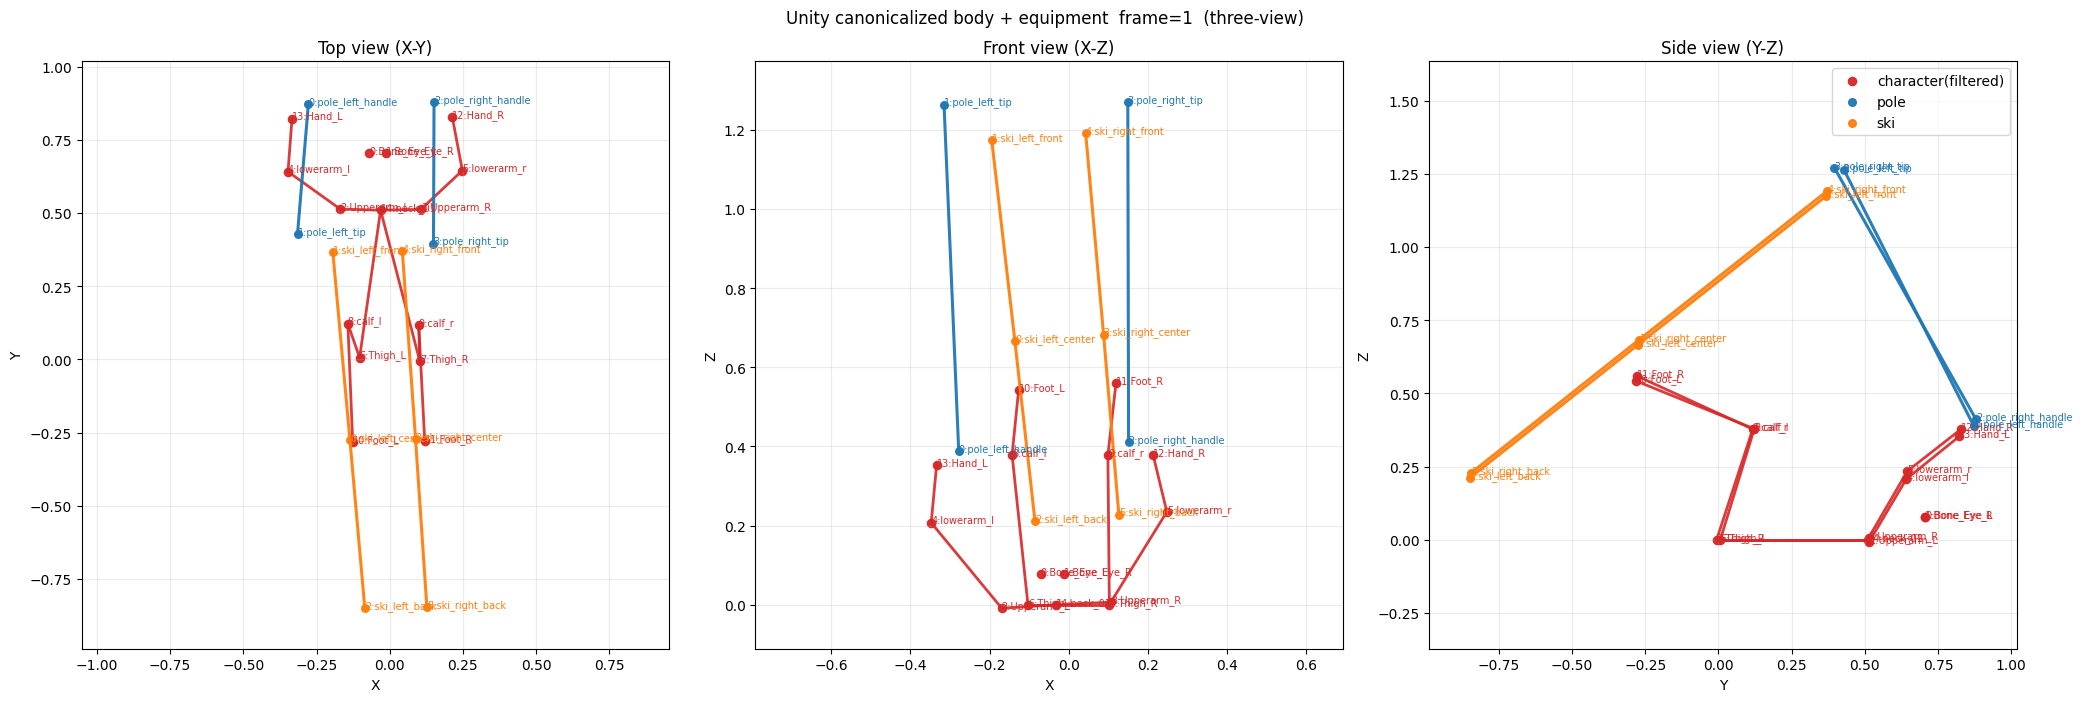

In [24]:
# ── Unity 原始 3D 关节验收可视化（含装备）: 三视图（俯视/正视/侧视）──────────────
pole_path = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "pole" / f"frame_{FRAME_IDX:06d}.npy"
ski_path = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt3d" / "ski" / f"frame_{FRAME_IDX:06d}.npy"

raw_unity = load_unity_character(FRAME_IDX, flag="3d")  # [15, 3]
pole_3d = np.load(pole_path).astype(np.float32)
ski_3d = np.load(ski_path).astype(np.float32)

raw_unity_canon, canon_tf = canonicalize_pose_numpy(
    raw_unity,
    left_hip=6,
    right_hip=7,
    neck=14,
    mode="first_frame",
    enforce_face_z_positive=True,
    left_eye=0,
    right_eye=1,
)

pole_3d = apply_canonical_transform_numpy(pole_3d, canon_tf["pelvis"], canon_tf["R"])
ski_3d = apply_canonical_transform_numpy(ski_3d, canon_tf["pelvis"], canon_tf["R"])

selected_pts = raw_unity_canon

print(f"Unity character shape: {raw_unity_canon.shape}")
print(f"Unity pole shape     : {pole_3d.shape}")
print(f"Unity ski shape      : {ski_3d.shape}")

all_xyz = np.concatenate([selected_pts, pole_3d, ski_3d], axis=0)

def _axis_limits_equal(xy: np.ndarray, pad_ratio: float = 0.08):
    mins = xy.min(axis=0)
    maxs = xy.max(axis=0)
    center = (mins + maxs) / 2.0
    span = np.max(maxs - mins)
    if span < 1e-6:
        span = 1.0
    half = span * (0.5 + pad_ratio)
    return center - half, center + half

def _draw_proj(
    ax,
    body: np.ndarray,
    pole: np.ndarray,
    ski: np.ndarray,
    dim_a: int,
    dim_b: int,
    title: str,
    xlabel: str,
    ylabel: str,
) -> None:
    ax.set_title(title)

    # 身体骨架
    ax.scatter(body[:, dim_a], body[:, dim_b], s=35, c="tab:red", alpha=0.95, label="character(filtered)")
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < body.shape[0] and j < body.shape[0]:
            ax.plot(
                [body[i, dim_a], body[j, dim_a]],
                [body[i, dim_b], body[j, dim_b]],
                color="tab:red", linewidth=2.0, alpha=0.9,
            )

    # 装备
    ax.scatter(pole[:, dim_a], pole[:, dim_b], s=30, c="tab:blue", alpha=0.95, label="pole")
    ax.scatter(ski[:, dim_a], ski[:, dim_b], s=30, c="tab:orange", alpha=0.95, label="ski")

    # pole 连线
    pole_edges = [(0, 1), (2, 3)] if len(pole) == 4 else [(k, k + 1) for k in range(len(pole) - 1)]
    for i, j in pole_edges:
        ax.plot(
            [pole[i, dim_a], pole[j, dim_a]],
            [pole[i, dim_b], pole[j, dim_b]],
            color="tab:blue", linewidth=2.2, alpha=0.95,
        )

    # ski 连线
    ski_edges = [(0, 1), (0, 2), (3, 4), (3, 5)] if len(ski) == 6 else [(k, k + 1) for k in range(len(ski) - 1)]
    for i, j in ski_edges:
        ax.plot(
            [ski[i, dim_a], ski[j, dim_a]],
            [ski[i, dim_b], ski[j, dim_b]],
            color="tab:orange", linewidth=2.2, alpha=0.95,
        )

    for idx, name in FILTERED_KPTS_MAPPING.items():
        ax.text(body[idx, dim_a], body[idx, dim_b], f"{idx}:{name}", fontsize=7, color="tab:red")
    for idx, name in POLE_MAPPING.items():
        ax.text(pole[idx, dim_a], pole[idx, dim_b], f"{idx}:{name}", fontsize=7, color="tab:blue")
    for idx, name in SKI_MAPPING.items():
        ax.text(ski[idx, dim_a], ski[idx, dim_b], f"{idx}:{name}", fontsize=7, color="tab:orange")

    lim_min, lim_max = _axis_limits_equal(all_xyz[:, [dim_a, dim_b]])
    ax.set_xlim(float(lim_min[0]), float(lim_max[0]))
    ax.set_ylim(float(lim_min[1]), float(lim_max[1]))
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"Unity canonicalized body + equipment  frame={FRAME_IDX}  (three-view)")

# 俯视: X-Y
_draw_proj(axes[0], selected_pts, pole_3d, ski_3d, 0, 1, "Top view (X-Y)", "X", "Y")
# 正视: X-Z
_draw_proj(axes[1], selected_pts, pole_3d, ski_3d, 0, 2, "Front view (X-Z)", "X", "Z")
# 侧视: Y-Z
_draw_proj(axes[2], selected_pts, pole_3d, ski_3d, 1, 2, "Side view (Y-Z)", "Y", "Z")

axes[2].legend(loc="upper right")
plt.tight_layout()
plt.show()

SAM3D canonical shape: (15, 3)


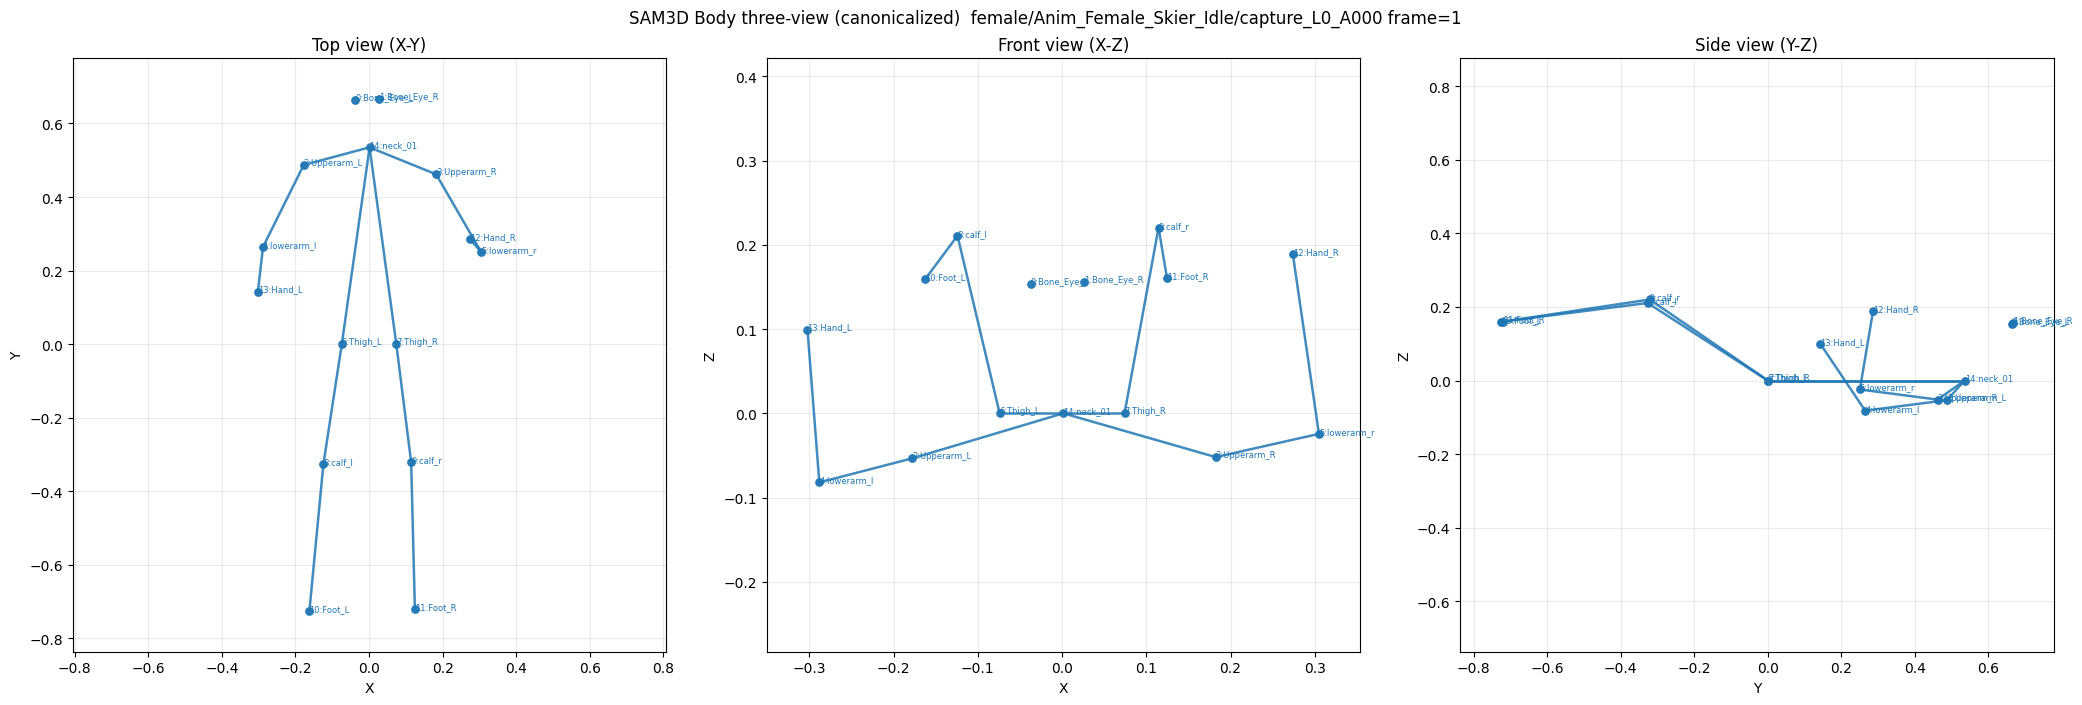

In [25]:
def draw_skeleton_2d_proj(
    ax,
    kpts: np.ndarray,
    dim_a: int,
    dim_b: int,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str = "tab:blue",
) -> None:
    ax.set_title(title)
    ax.scatter(kpts[:, dim_a], kpts[:, dim_b], s=28, c=color, alpha=0.95)

    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < kpts.shape[0] and j < kpts.shape[0]:
            ax.plot(
                [kpts[i, dim_a], kpts[j, dim_a]],
                [kpts[i, dim_b], kpts[j, dim_b]],
                color=color, linewidth=1.8, alpha=0.85,
            )

    for idx, name in FILTERED_KPTS_MAPPING.items():
        ax.text(
            kpts[idx, dim_a],
            kpts[idx, dim_b],
            f"{idx}:{name}",
            fontsize=6,
            color=color,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.set_aspect("equal", adjustable="box")

def axis_limits_equal(xy: np.ndarray, pad_ratio: float = 0.08):
    mins = xy.min(axis=0)
    maxs = xy.max(axis=0)
    center = (mins + maxs) / 2.0
    span = np.max(maxs - mins)
    if span < 1e-6:
        span = 1.0
    half = span * (0.5 + pad_ratio)
    return center - half, center + half

# SAM3D body canonicalize（按自身骨架 + 强制面朝 +Z）
sam3d_kpt_canon, _ = canonicalize_pose_numpy(
    sam3d_kpt,
    left_hip=6,
    right_hip=7,
    neck=14,
    mode="first_frame",
    enforce_face_z_positive=True,
    left_eye=0,
    right_eye=1,
)

print("SAM3D canonical shape:", sam3d_kpt_canon.shape)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"SAM3D Body three-view (canonicalized)  {GENDER}/{ACTION}/{CAMERA} frame={FRAME_IDX}")

draw_skeleton_2d_proj(
    axes[0], sam3d_kpt_canon, 0, 1, "Top view (X-Y)", "X", "Y", color="tab:blue"
)
draw_skeleton_2d_proj(
    axes[1], sam3d_kpt_canon, 0, 2, "Front view (X-Z)", "X", "Z", color="tab:blue"
)
draw_skeleton_2d_proj(
    axes[2], sam3d_kpt_canon, 1, 2, "Side view (Y-Z)", "Y", "Z", color="tab:blue"
)

# 统一各子图尺度，便于对比
for ax, dims in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    lim_min, lim_max = axis_limits_equal(sam3d_kpt_canon[:, [dims[0], dims[1]]])
    ax.set_xlim(float(lim_min[0]), float(lim_max[0]))
    ax.set_ylim(float(lim_min[1]), float(lim_max[1]))

plt.tight_layout()
plt.show()

(98, 3)
Unity 2D kpt shape: (15, 2)
SAM3D 2D kpt shape: (15, 2)


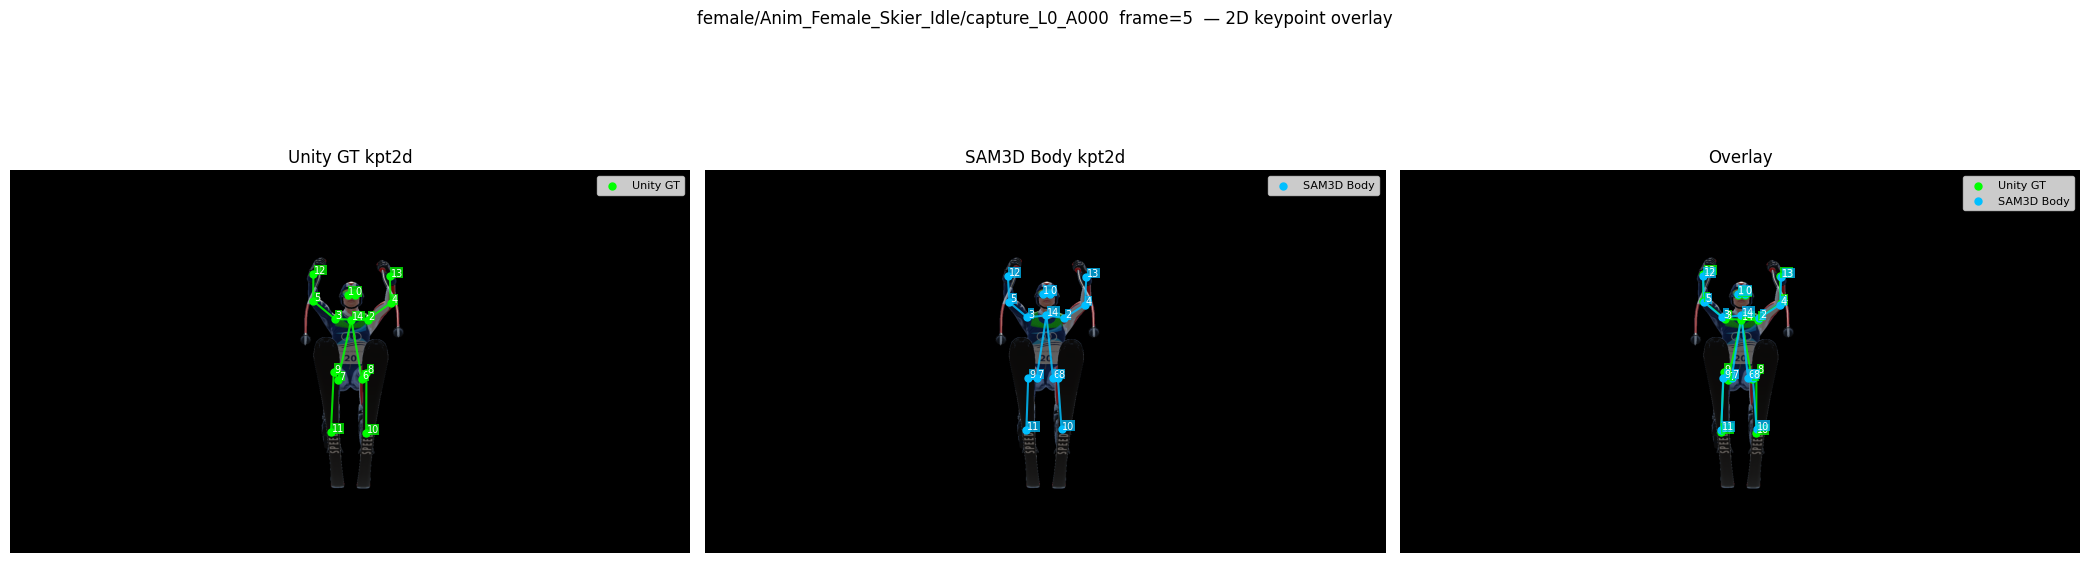

In [26]:
import cv2

# Unity GT kpt2d 子目录名去掉 capture_ 前缀
FRAME_IDX = 5
CAM_SHORT = CAMERA.replace("capture_", "")   # e.g. "L0_A000"

GENDER = "female"
ACTION = "Anim_Female_Skier_Idle"
frame_dir       = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "frames" / CAMERA
unity_kpt2d_dir = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character"
sam3d_kpt2d_dir = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt2d" / CAMERA

def load_unity_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 Unity GT 2D 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    print(raw.shape)
    return filter_unity_kpts(raw, flag="2d", gender=GENDER)          # [15, 2]

def load_sam3d_body_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 2D 关键点（kpt2d），过滤到 15 关节。"""
    path = sam3d_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 2) → (J, 2)
    return filter_sam3d_body_kpts(raw)     # [15, 2]

def draw_kpts_on_image(ax, img_rgb: np.ndarray,
                       kpts: np.ndarray, color: str, label: str,
                       radius: int = 5, linewidth: float = 1.5,
                       show_indices: bool = True) -> None:
    """在图像上绘制关键点和骨骼连线。"""
    ax.imshow(img_rgb)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=radius**2, c=color, zorder=3, label=label)
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < len(kpts) and j < len(kpts):
            ax.plot(
                [kpts[i, 0], kpts[j, 0]],
                [kpts[i, 1], kpts[j, 1]],
                color=color, linewidth=linewidth, alpha=0.85, zorder=2,
            )

    if show_indices:
        for idx, (x, y) in enumerate(kpts):
            ax.text(
                x + 2,
                y - 2,
                str(idx),
                fontsize=7,
                color="white",
                zorder=4,
                bbox=dict(facecolor=color, edgecolor="none", alpha=0.75, pad=0.2),
            )

    ax.axis("off")


# ── 加载图片和 2D kpt ────────────────────────────────────────────────────────
img_path   = frame_dir / f"frame_{FRAME_IDX:06d}.png"
img_bgr    = cv2.imread(str(img_path))
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

unity_kpt2d = load_unity_kpt2d(frame_idx=FRAME_IDX)[:, :2]  # 可能有多余维度，取前两列
sam3d_kpt2d = load_sam3d_body_kpt2d(frame_idx=FRAME_IDX)

print("Unity 2D kpt shape:", unity_kpt2d.shape)
print("SAM3D 2D kpt shape:", sam3d_kpt2d.shape)

# ── 可视化 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}  — 2D keypoint overlay")

# Panel 1: Unity GT
draw_kpts_on_image(axes[0], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
axes[0].set_title("Unity GT kpt2d")
axes[0].legend(loc="upper right", fontsize=8)

# Panel 2: SAM3D Body
draw_kpts_on_image(axes[1], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[1].set_title("SAM3D Body kpt2d")
axes[1].legend(loc="upper right", fontsize=8)

# Panel 3: 叠加对比
draw_kpts_on_image(axes[2], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
draw_kpts_on_image(axes[2], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[2].set_title("Overlay")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


(97, 3)
Unity 2D kpt shape: (15, 2)
SAM3D 2D kpt shape: (15, 2)


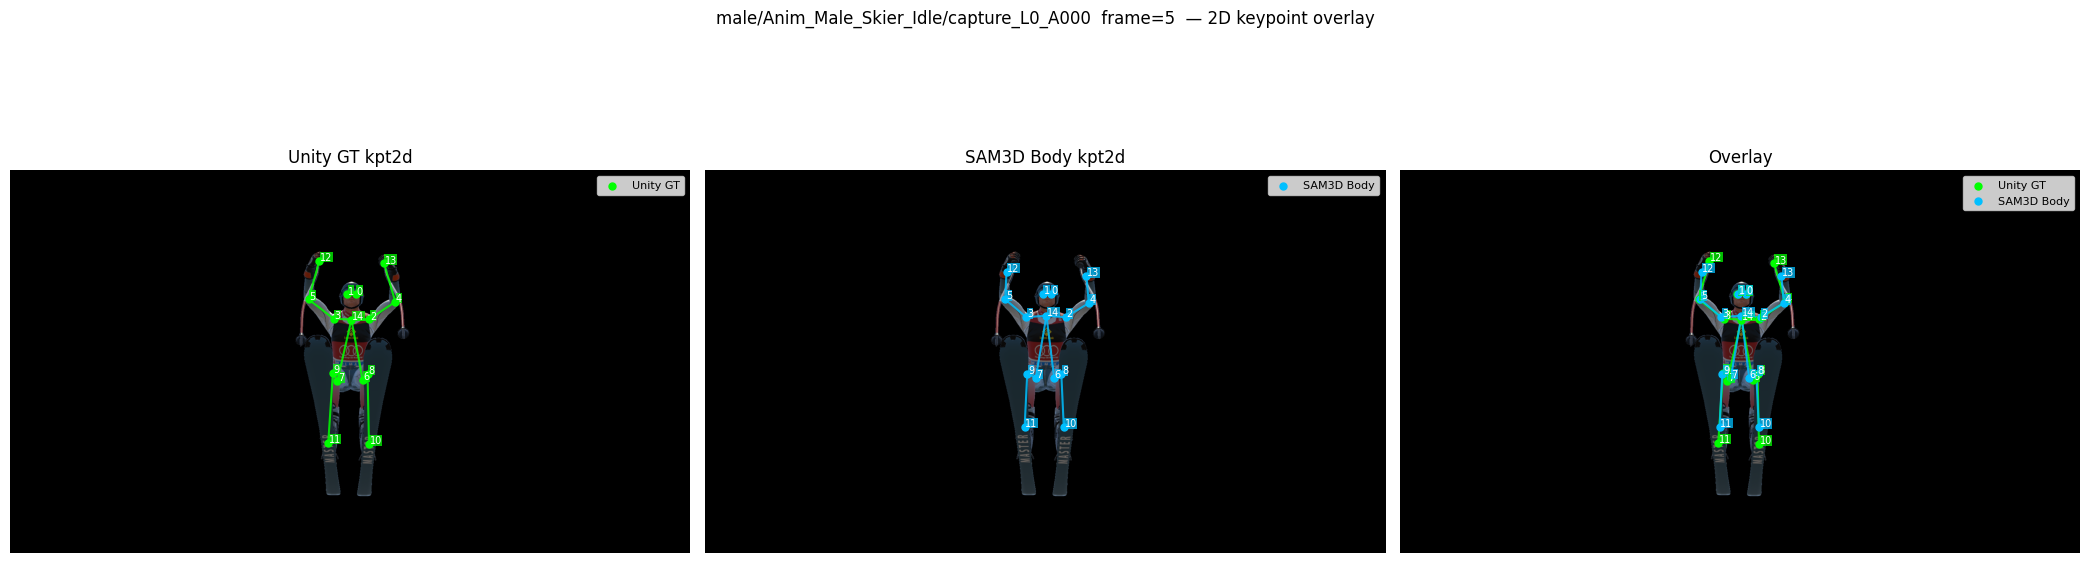

In [27]:
import cv2

# Unity GT kpt2d 子目录名去掉 capture_ 前缀
FRAME_IDX = 5
CAM_SHORT = CAMERA.replace("capture_", "")   # e.g. "L0_A000"

GENDER = "male"
ACTION = "Anim_Male_Skier_Idle"
frame_dir       = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "frames" / CAMERA
unity_kpt2d_dir = DATA_ROOT / "data_pole_ski" / GENDER / ACTION / "kpt2d" / CAM_SHORT / "character"
sam3d_kpt2d_dir = DATA_ROOT / "sam3d_body_results/modalities_from_sam3d" / GENDER / ACTION / "kpt2d" / CAMERA

def load_unity_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 Unity GT 2D 关键点并转换到 SAM3D 坐标系，再过滤到 15 关节。"""
    path = unity_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    raw = np.load(path).astype(np.float32)
    print(raw.shape)
    return filter_unity_kpts(raw, flag="2d", gender=GENDER)          # [15, 2]

def load_sam3d_body_kpt2d(frame_idx: int) -> np.ndarray:
    """读取 SAM3D body 2D 关键点（kpt2d），过滤到 15 关节。"""
    path = sam3d_kpt2d_dir / f"kpt2d_{frame_idx:06d}.npy"
    data = np.load(path, allow_pickle=True)
    raw = np.asarray(data).astype(np.float32)
    if raw.ndim == 3:
        raw = raw[0]           # (1, J, 2) → (J, 2)
    return filter_sam3d_body_kpts(raw)     # [15, 2]

def draw_kpts_on_image(ax, img_rgb: np.ndarray,
                       kpts: np.ndarray, color: str, label: str,
                       radius: int = 5, linewidth: float = 1.5,
                       show_indices: bool = True) -> None:
    """在图像上绘制关键点和骨骼连线。"""
    ax.imshow(img_rgb)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=radius**2, c=color, zorder=3, label=label)
    for i, j in FILTER_SKELETON_CONNECTIONS:
        if i < len(kpts) and j < len(kpts):
            ax.plot(
                [kpts[i, 0], kpts[j, 0]],
                [kpts[i, 1], kpts[j, 1]],
                color=color, linewidth=linewidth, alpha=0.85, zorder=2,
            )

    if show_indices:
        for idx, (x, y) in enumerate(kpts):
            ax.text(
                x + 2,
                y - 2,
                str(idx),
                fontsize=7,
                color="white",
                zorder=4,
                bbox=dict(facecolor=color, edgecolor="none", alpha=0.75, pad=0.2),
            )

    ax.axis("off")


# ── 加载图片和 2D kpt ────────────────────────────────────────────────────────
img_path   = frame_dir / f"frame_{FRAME_IDX:06d}.png"
img_bgr    = cv2.imread(str(img_path))
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

unity_kpt2d = load_unity_kpt2d(frame_idx=FRAME_IDX)[:, :2]  # 可能有多余维度，取前两列
sam3d_kpt2d = load_sam3d_body_kpt2d(frame_idx=FRAME_IDX)

print("Unity 2D kpt shape:", unity_kpt2d.shape)
print("SAM3D 2D kpt shape:", sam3d_kpt2d.shape)

# ── 可视化 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"{GENDER}/{ACTION}/{CAMERA}  frame={FRAME_IDX}  — 2D keypoint overlay")

# Panel 1: Unity GT
draw_kpts_on_image(axes[0], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
axes[0].set_title("Unity GT kpt2d")
axes[0].legend(loc="upper right", fontsize=8)

# Panel 2: SAM3D Body
draw_kpts_on_image(axes[1], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[1].set_title("SAM3D Body kpt2d")
axes[1].legend(loc="upper right", fontsize=8)

# Panel 3: 叠加对比
draw_kpts_on_image(axes[2], img_rgb, unity_kpt2d,
                   color="lime", label="Unity GT", show_indices=True)
draw_kpts_on_image(axes[2], img_rgb, sam3d_kpt2d,
                   color="deepskyblue", label="SAM3D Body", show_indices=True)
axes[2].set_title("Overlay")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()